In [ ]:
# !cp "/content/drive/MyDrive/Colab_Notebooks/train.tar.gz" "/content/"
# !cp "/content/drive/MyDrive/Colab_Notebooks/test.tar.gz" "/content/"
# !tar -xzf train.tar.gz
# !tar -xzf test.tar.gz
TRAIN_DATASET_DIR = "/content/train"
TEST_DATASET_DIR = "/content/test"
TRAIN_MAT_PATH = "/content/train/digitStruct.mat"
TEST_MAT_PATH = "/content/test/digitStruct.mat"
TRAIN_LABELS_DIR = "/content/train/labels"
TEST_LABELS_DIR = "/content/test/labels"

In [5]:
import os
import shutil
import random
import torch
from PIL import Image
from tqdm import tqdm
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import h5py
import numpy as np
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Подготовка датасета

In [ ]:
os.makedirs(TRAIN_LABELS_DIR, exist_ok=True)
os.makedirs(TEST_LABELS_DIR, exist_ok=True)

def read_string(mat_file, ref):
    return ''.join(chr(c[0]) for c in mat_file[ref][()])

def read_bbox_value(mat_file, item):
    values = []
    for i in range(len(item)):
        val = item[i][0]
        if isinstance(val, h5py.Reference):
            values.append(float(mat_file[val][()][0][0]))
        else:
            values.append(float(val))
    return values

def parse_digit_struct(mat_path):
    data = []
    with h5py.File(mat_path, "r") as f:
        digitStruct = f["digitStruct"]
        names = digitStruct["name"]
        bboxes = digitStruct["bbox"]

        for i in range(len(names)):
            name_ref = names[i][0]
            img_name = read_string(f, name_ref)

            bbox_ref = bboxes[i][0]
            bbox_group = f[bbox_ref]

            lefts = read_bbox_value(f, bbox_group["left"])
            tops = read_bbox_value(f, bbox_group["top"])
            widths = read_bbox_value(f, bbox_group["width"])
            heights = read_bbox_value(f, bbox_group["height"])
            labels = read_bbox_value(f, bbox_group["label"])

            boxes = []
            for l, t, w, h, lab in zip(lefts, tops, widths, heights, labels):
                lab = int(lab)
                if lab == 10:
                    lab = 0

                boxes.append({
                    "label": lab,
                    "left": l,
                    "top": t,
                    "width": w,
                    "height": h
                })

            data.append({
                "filename": img_name,
                "boxes": boxes
            })

    return data

def convert_to_yolo(dataset_dir, labels_dir, annotations):
    for item in tqdm(annotations):
        img_path = os.path.join(dataset_dir, item["filename"])
        if not os.path.exists(img_path):
            continue

        with Image.open(img_path) as img:
            img_w, img_h = img.size

        label_filename = os.path.splitext(item["filename"])[0] + ".txt"
        label_path = os.path.join(labels_dir, label_filename)

        lines = []
        for box in item["boxes"]:
            cls = box["label"]
            left = box["left"]
            top = box["top"]
            width = box["width"]
            height = box["height"]

            x_center = (left + width / 2.0) / img_w
            y_center = (top + height / 2.0) / img_h
            w = width / img_w
            h = height / img_h

            x_center = min(max(x_center, 0.0), 1.0)
            y_center = min(max(y_center, 0.0), 1.0)
            w = min(max(w, 0.0), 1.0)
            h = min(max(h, 0.0), 1.0)

            lines.append(f"{cls} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}")

        with open(label_path, "w") as f:
            f.write("\n".join(lines))

train_annotations = parse_digit_struct(TRAIN_MAT_PATH)
test_annotations = parse_digit_struct(TEST_MAT_PATH)
convert_to_yolo(TRAIN_DATASET_DIR, TRAIN_LABELS_DIR, train_annotations)
convert_to_yolo(TEST_DATASET_DIR, TEST_LABELS_DIR, test_annotations)

100%|██████████| 13068/13068 [00:01<00:00, 6934.71it/s]


In [ ]:
OUT_DIR = "/content/dataset"

for split in ["train", "test"]:
    src_img_dir = f"/content/{split}"
    src_lbl_dir = f"/content/{split}/labels"

    dst_img_dir = os.path.join(OUT_DIR, "images", split)
    dst_lbl_dir = os.path.join(OUT_DIR, "labels", split)

    os.makedirs(dst_img_dir, exist_ok=True)
    os.makedirs(dst_lbl_dir, exist_ok=True)

    for f in os.listdir(src_img_dir):
        if f.endswith(".png"):
            shutil.copy(os.path.join(src_img_dir, f), os.path.join(dst_img_dir, f))

    for f in os.listdir(src_lbl_dir):
        if f.endswith(".txt"):
            shutil.copy(os.path.join(src_lbl_dir, f), os.path.join(dst_lbl_dir, f))


In [ ]:
BASE = "/content/dataset"
IMG_TRAIN = os.path.join(BASE, "images/train")
LBL_TRAIN = os.path.join(BASE, "labels/train")
IMG_VAL = os.path.join(BASE, "images/val")
LBL_VAL = os.path.join(BASE, "labels/val")

os.makedirs(IMG_VAL, exist_ok=True)
os.makedirs(LBL_VAL, exist_ok=True)

VAL_RATIO = 0.1

images = [f for f in os.listdir(IMG_TRAIN) if f.endswith(".png")]
random.shuffle(images)

val_count = int(len(images) * VAL_RATIO)
val_images = images[:val_count]

for img_name in val_images:
    base_name = os.path.splitext(img_name)[0]
    lbl_name = base_name + ".txt"

    src_img = os.path.join(IMG_TRAIN, img_name)
    src_lbl = os.path.join(LBL_TRAIN, lbl_name)

    dst_img = os.path.join(IMG_VAL, img_name)
    dst_lbl = os.path.join(LBL_VAL, lbl_name)

    shutil.move(src_img, dst_img)

    if os.path.exists(src_lbl):
        shutil.move(src_lbl, dst_lbl)
    else:
        print(f"нет label для {img_name}")

In [ ]:
data_yaml = """
path: /content/dataset
train: images/train
val: images/val
test: images/test

names:
  0: "0"
  1: "1"
  2: "2"
  3: "3"
  4: "4"
  5: "5"
  6: "6"
  7: "7"
  8: "8"
  9: "9"
"""

with open("/content/data.yaml", "w") as f:
    f.write(data_yaml)

# YOLO

In [ ]:
model = YOLO("yolo26n.pt")
model.train(
    data="/content/data.yaml",
    epochs=20,
    imgsz=320,
    batch=64,
    device=0,
    plots=True,
    workers=4,
)

Ultralytics 8.4.26 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=T

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ef68daf60f0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0

In [ ]:
metrics = model.val(
    data="/content/data.yaml",
    split="test"
)

Ultralytics 8.4.26 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 523.9±616.2 MB/s, size: 28.8 KB)
val: Scanning /content/dataset/labels/test.cache... 13068 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 13068/13068 4.2Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 817/817 13.0it/s 1:03
                   all      13068      26032      0.876      0.796      0.867      0.416
                     0       1687       1744      0.886      0.822      0.897      0.443
                     1       4578       5099      0.847       0.74      0.819      0.338
                     2       3834       4149      0.897      0.822       0.89      0.434
                     3       2696       2882      0.868      0.756      0.846       0.41
                     4       2397       2523       0.88      0.837      0.873      0.405
                     5       2290 

# Проверка на своих изображениях


0: 320x320 1 1, 1 8, 5.9ms
1: 320x320 1 0, 2 1s, 1 5, 5.9ms
Speed: 1.0ms preprocess, 5.9ms inference, 0.3ms postprocess per image at shape (1, 3, 320, 320)


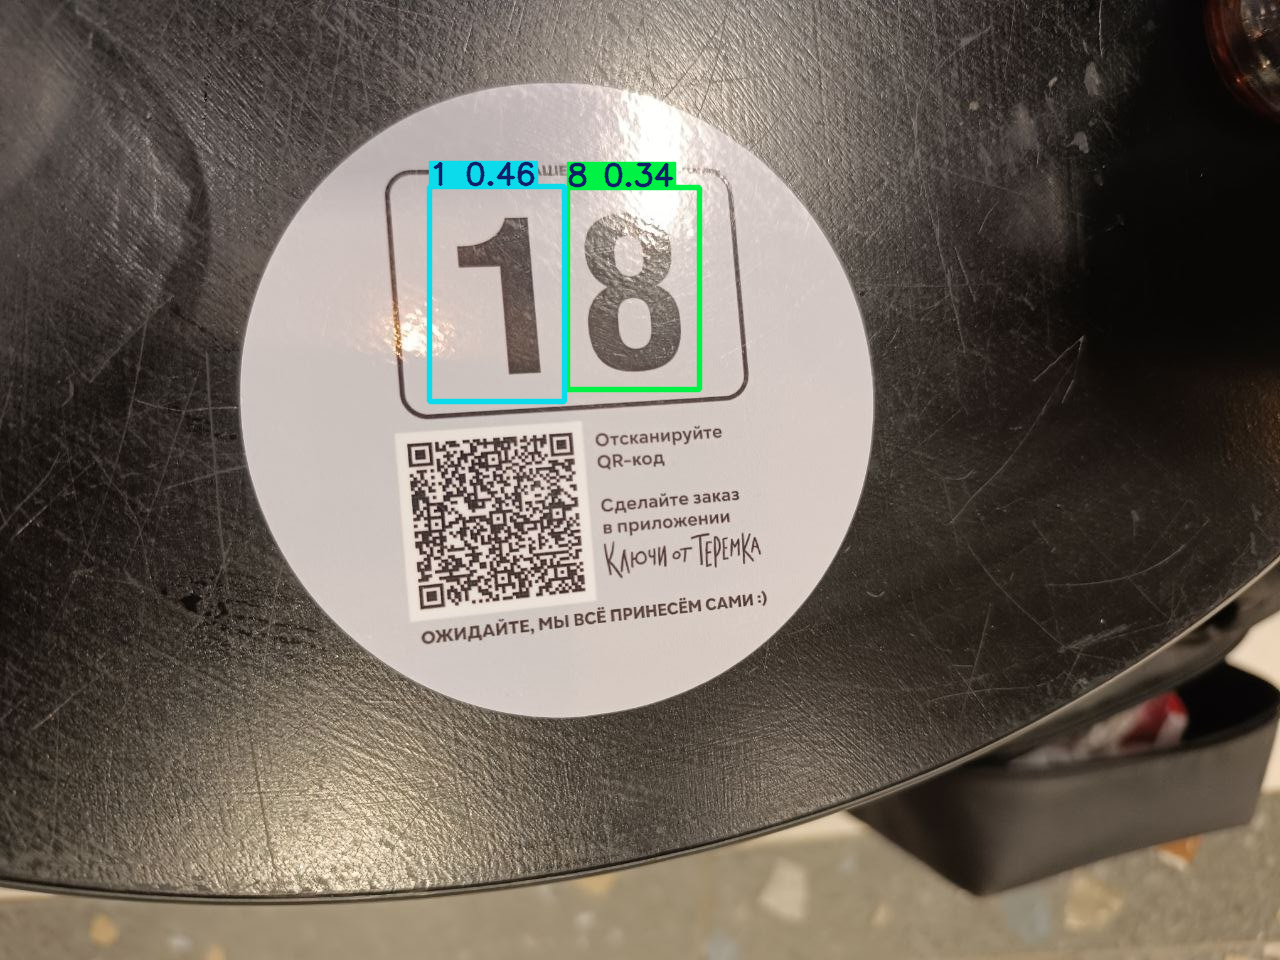

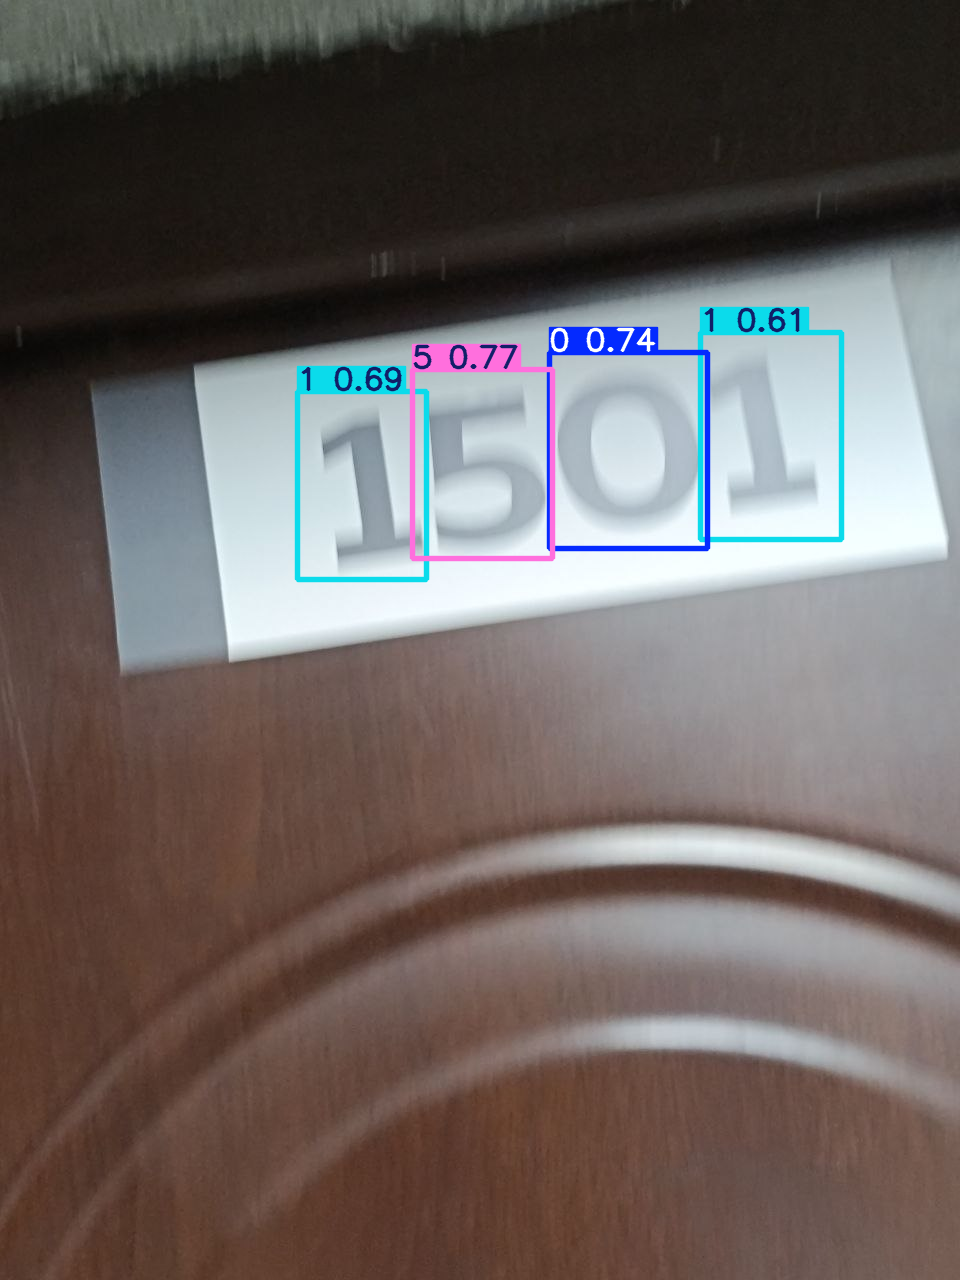

In [ ]:
results = model(["/content/1.jpg", "/content/2.jpg"])
for result in results:
    result.show()

упс

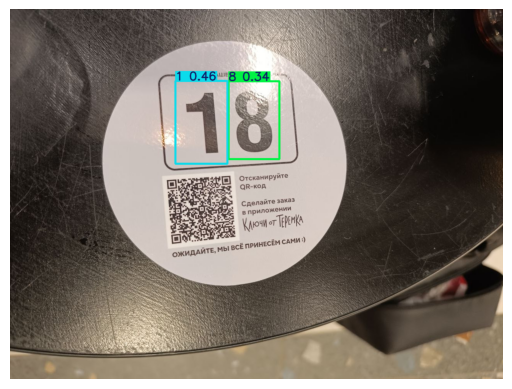

In [11]:
img = Image.open("/content/first.png")
plt.imshow(img)
plt.axis('off')
plt.show()

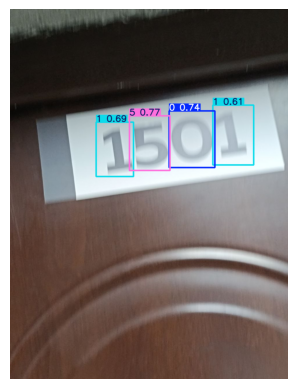

In [12]:
img = Image.open("/content/second.png")
plt.imshow(img)
plt.axis('off')
plt.show()